In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('Mall_Customers.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

Basic Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36

In [4]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected and scaled successfully!")
print(f"Shape: {X_scaled.shape}")

Features selected and scaled successfully!
Shape: (200, 2)


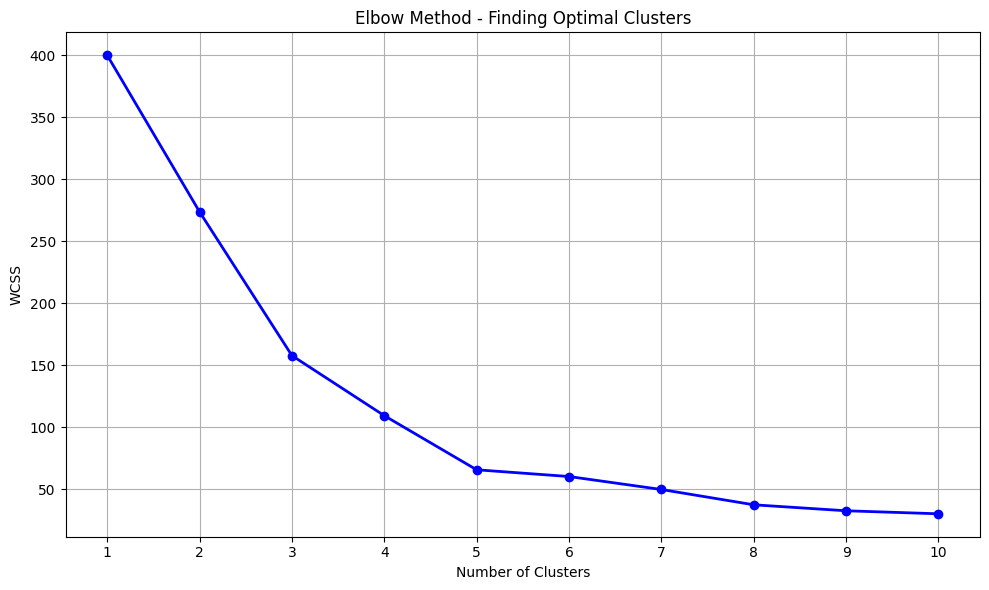

Look for the 'elbow' point in the graph!


In [5]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', color='blue', linewidth=2)
plt.title('Elbow Method - Finding Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_method.png')
plt.show()

print("Look for the 'elbow' point in the graph!")

In [6]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_

print("K-Means model trained successfully!")
print(f"\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

K-Means model trained successfully!

Cluster Distribution:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


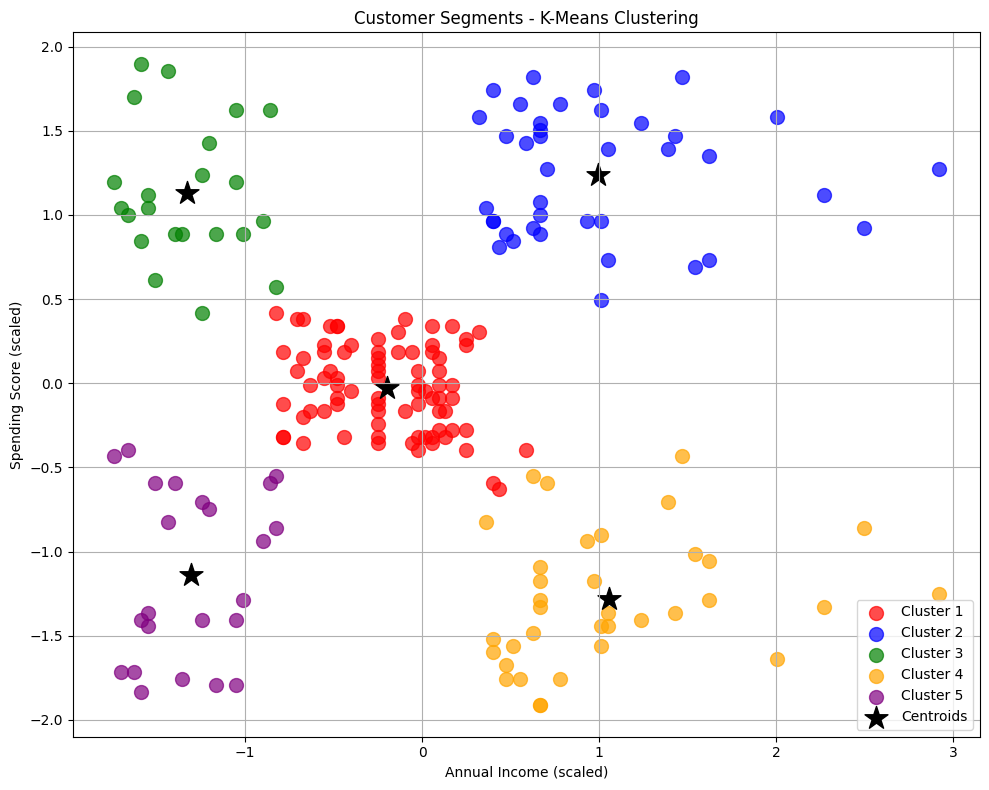

In [7]:
plt.figure(figsize=(10, 8))

colors = ['red', 'blue', 'green', 'orange', 'purple']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

for i in range(5):
    plt.scatter(X_scaled[kmeans.labels_ == i, 0],
                X_scaled[kmeans.labels_ == i, 1],
                s=100, c=colors[i], label=labels[i], alpha=0.7)

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, c='black', marker='*', label='Centroids')

plt.title('Customer Segments - K-Means Clustering')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('customer_clusters.png')
plt.show()

In [8]:
print("📊 Cluster Analysis")
print("="*50)

cluster_names = {
    0: '😊 Average Customers',
    1: '💎 Premium Customers',
    2: '🛍️ Impulsive Buyers',
    3: '💰 Careful Spenders',
    4: '😴 Budget Customers'
}

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    print(f"\nCluster {i} - {cluster_names[i]}:")
    print(f"  Total Customers : {len(cluster_data)}")
    print(f"  Avg Age         : {cluster_data['Age'].mean():.1f}")
    print(f"  Avg Income      : ${cluster_data['Annual Income (k$)'].mean():.1f}k")
    print(f"  Avg Spending    : {cluster_data['Spending Score (1-100)'].mean():.1f}/100")

📊 Cluster Analysis

Cluster 0 - 😊 Average Customers:
  Total Customers : 81
  Avg Age         : 42.7
  Avg Income      : $55.3k
  Avg Spending    : 49.5/100

Cluster 1 - 💎 Premium Customers:
  Total Customers : 39
  Avg Age         : 32.7
  Avg Income      : $86.5k
  Avg Spending    : 82.1/100

Cluster 2 - 🛍️ Impulsive Buyers:
  Total Customers : 22
  Avg Age         : 25.3
  Avg Income      : $25.7k
  Avg Spending    : 79.4/100

Cluster 3 - 💰 Careful Spenders:
  Total Customers : 35
  Avg Age         : 41.1
  Avg Income      : $88.2k
  Avg Spending    : 17.1/100

Cluster 4 - 😴 Budget Customers:
  Total Customers : 23
  Avg Age         : 45.2
  Avg Income      : $26.3k
  Avg Spending    : 20.9/100


<Figure size 1000x600 with 0 Axes>

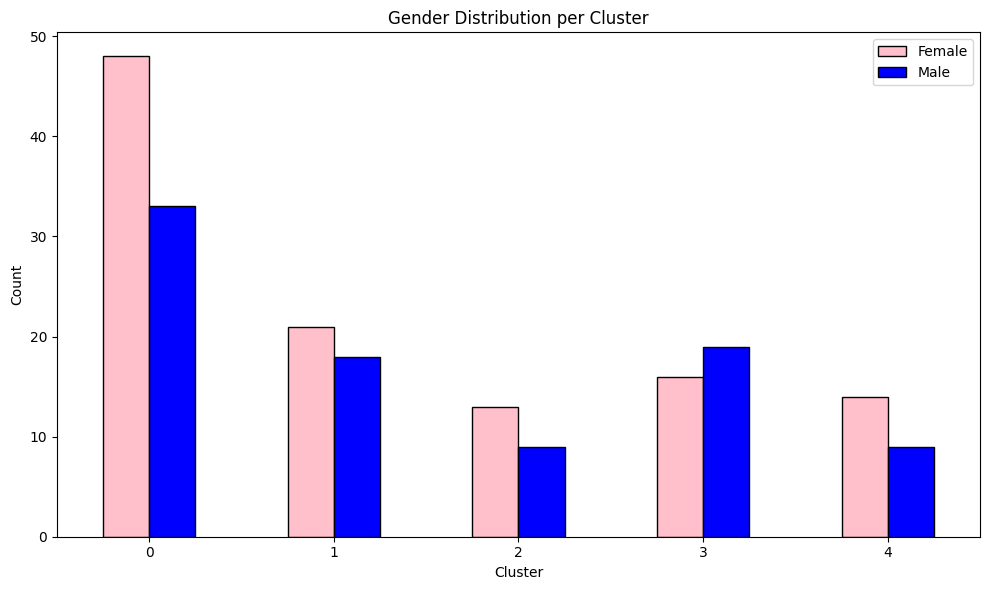

In [9]:
plt.figure(figsize=(10, 6))
gender_cluster = df.groupby(['Cluster', 'Gender']).size().unstack()
gender_cluster.plot(kind='bar', color=['pink', 'blue'], 
                    figsize=(10, 6), edgecolor='black')
plt.title('Gender Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Female', 'Male'])
plt.tight_layout()
plt.savefig('gender_distribution.png')
plt.show()

<Figure size 1000x600 with 0 Axes>

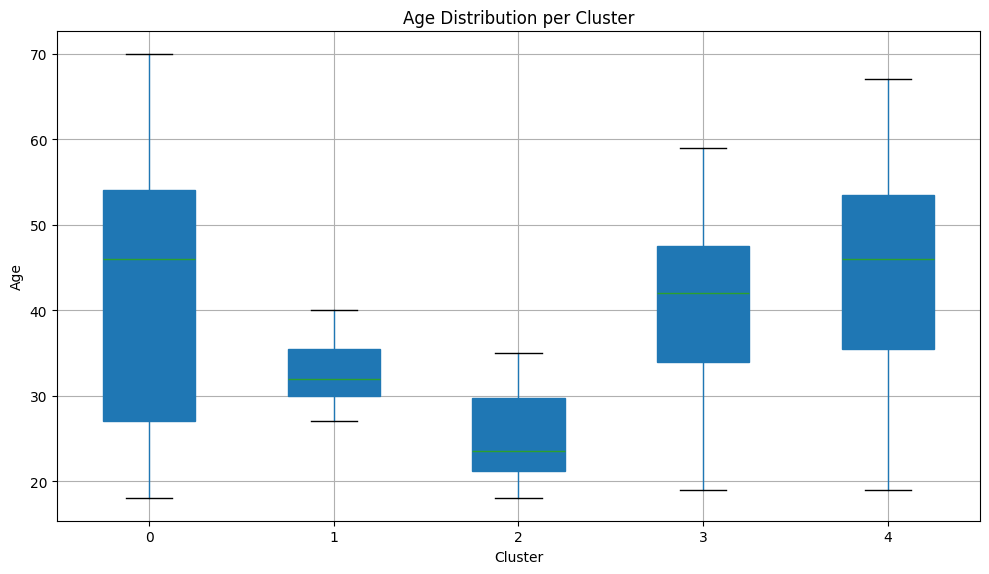

In [10]:
plt.figure(figsize=(10, 6))
df.boxplot(column='Age', by='Cluster', 
           patch_artist=True,
           figsize=(10, 6))
plt.title('Age Distribution per Cluster')
plt.suptitle('')
plt.xlabel('Cluster')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()

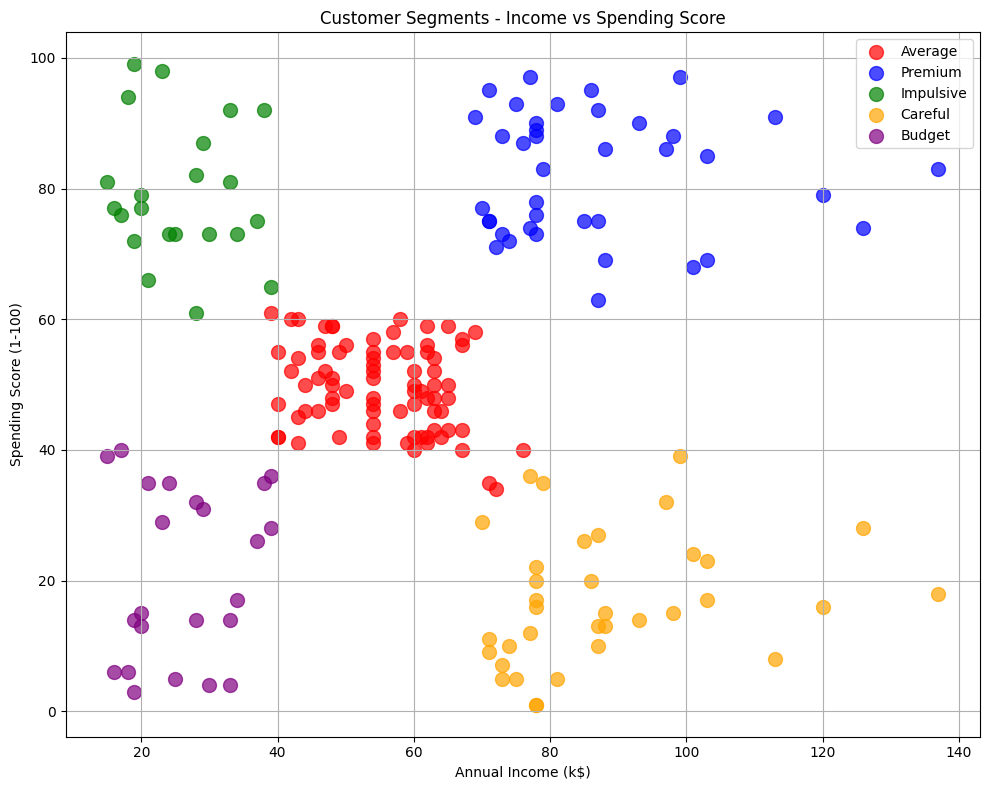

In [11]:
plt.figure(figsize=(10, 8))

colors = ['red', 'blue', 'green', 'orange', 'purple']
cluster_names = ['Average', 'Premium', 'Impulsive', 'Careful', 'Budget']

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                s=100, c=colors[i], label=cluster_names[i], alpha=0.7)

plt.title('Customer Segments - Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('income_vs_spending.png')
plt.show()

In [12]:
print("🛍️ Custom Customer Segment Predictor")
print("="*40)

custom_customer = pd.DataFrame({
    'Annual Income (k$)': [80],
    'Spending Score (1-100)': [70]
})

custom_scaled = scaler.transform(custom_customer)
predicted_cluster = kmeans.predict(custom_scaled)

cluster_names = {
    0: '😊 Average Customer',
    1: '💎 Premium Customer',
    2: '🛍️ Impulsive Buyer',
    3: '💰 Careful Spender',
    4: '😴 Budget Customer'
}

print(f"\nCustomer Details:")
print(f"  - Annual Income : $80k")
print(f"  - Spending Score: 70/100")
print(f"\n🎯 Predicted Segment: {cluster_names[predicted_cluster[0]]}")

🛍️ Custom Customer Segment Predictor

Customer Details:
  - Annual Income : $80k
  - Spending Score: 70/100

🎯 Predicted Segment: 💎 Premium Customer


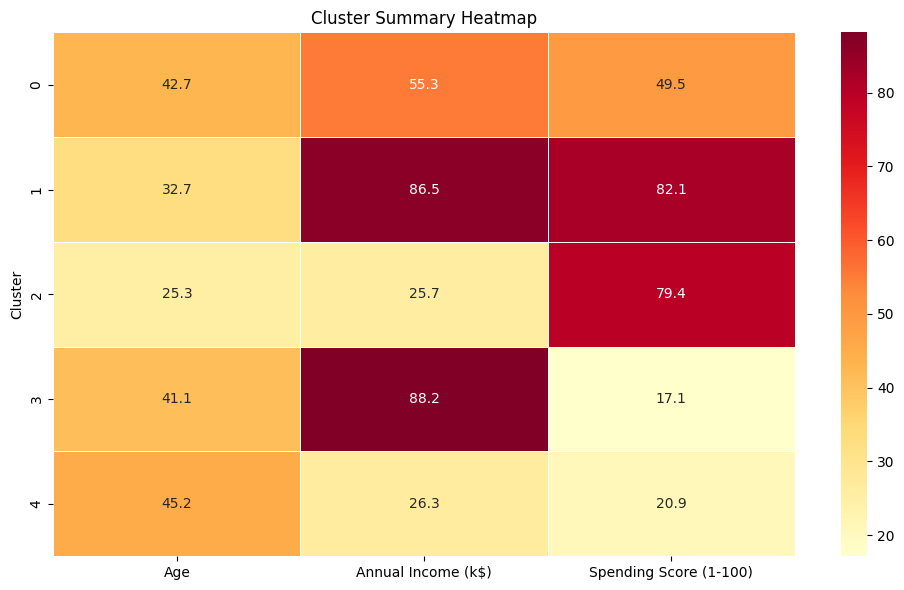

In [13]:
plt.figure(figsize=(10, 6))

cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 
                                          'Spending Score (1-100)']].mean()

sns.heatmap(cluster_summary, annot=True, fmt='.1f', 
            cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Summary Heatmap')
plt.tight_layout()
plt.savefig('cluster_heatmap.png')
plt.show()